# 03 — Modelos de Machine Learning Clásico

**Reto 2 — IA avanzada en Business Analytics | Odisea Data**

**Objetivo:** Entrenar y comparar varios modelos de ML clásico para predecir la propensión a comprar un seguro de vehículo.

**Modelos a comparar:**
1. Regresión Logística (baseline)
2. Random Forest
3. XGBoost
4. LightGBM

**Métricas:** F1-score, Recall, Precision, AUC-ROC (adecuadas para datasets desbalanceados).

**Estrategia contra el desbalanceo:**
- `class_weight="balanced"` en RF y LR
- `scale_pos_weight` en XGBoost
- `is_unbalance=True` en LightGBM



In [10]:
# ============================================================
# CREAR ESTRUCTURA DE CARPETAS EN COLAB
# ============================================================
import os

carpetas = [
    "outputs/charts",
    "outputs/metrics",
    "outputs/screenshots",
    "models/trained",
    "models/scalers",
]

for c in carpetas:
    os.makedirs(c, exist_ok=True)
    print(f"✅ {c}")

✅ outputs/charts
✅ outputs/metrics
✅ outputs/screenshots
✅ models/trained
✅ models/scalers


In [1]:
# ============================================================
# IMPORTS Y CONFIGURACIÓN
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import time
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("✅ Librerías cargadas")

✅ Librerías cargadas


In [3]:
from google.colab import files
uploaded = files.upload()

Saving test_processed.csv to test_processed.csv
Saving train_processed.csv to train_processed.csv


In [4]:
# ============================================================
# CARGA DE DATOS PROCESADOS
# ============================================================
train = pd.read_csv("/content/train_processed.csv")
test = pd.read_csv("/content/test_processed.csv")

X_train = train.drop(columns=["Response"])
y_train = train["Response"]
X_test = test.drop(columns=["Response"])
y_test = test["Response"]

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"\nDistribución de y_train: {dict(y_train.value_counts(normalize=True).round(4))}")

X_train: (304887, 10)
X_test:  (76222, 10)

Distribución de y_train: {0: np.float64(0.8774), 1: np.float64(0.1226)}


In [5]:
# ============================================================
# PARÁMETRO PARA DESBALANCEO
# ============================================================
# scale_pos_weight = ratio entre clase negativa y positiva
# Ayuda a XGBoost a dar más peso a la clase minoritaria
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f"scale_pos_weight: {scale_pos_weight:.2f}")

scale_pos_weight: 7.16


In [6]:
# ============================================================
# DEFINICIÓN DE MODELOS
# ============================================================
modelos = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_SEED,
        n_jobs=-1,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=RANDOM_SEED,
        n_jobs=-1,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        eval_metric="auc",
        random_state=RANDOM_SEED,
        n_jobs=-1,
        use_label_encoder=False,
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        is_unbalance=True,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbose=-1,
    ),
}

print(f"✅ {len(modelos)} modelos definidos:")
for nombre in modelos:
    print(f"  - {nombre}")

✅ 4 modelos definidos:
  - Logistic Regression
  - Random Forest
  - XGBoost
  - LightGBM


In [7]:
# ============================================================
# ENTRENAMIENTO Y EVALUACIÓN
# ============================================================
resultados = []
modelos_entrenados = {}

for nombre, modelo in modelos.items():
    print(f"\n{'='*60}")
    print(f"🚀 Entrenando: {nombre}")
    print('='*60)

    # Entrenar
    t0 = time.time()
    modelo.fit(X_train, y_train)
    tiempo = time.time() - t0

    # Predecir
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    # Métricas
    metricas = {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_proba),
        "Tiempo (s)": round(tiempo, 2),
    }
    resultados.append(metricas)
    modelos_entrenados[nombre] = modelo

    # Mostrar resultados
    print(f"  Accuracy:  {metricas['Accuracy']:.4f}")
    print(f"  Precision: {metricas['Precision']:.4f}")
    print(f"  Recall:    {metricas['Recall']:.4f}")
    print(f"  F1-score:  {metricas['F1']:.4f}")
    print(f"  AUC-ROC:   {metricas['AUC-ROC']:.4f}")
    print(f"  Tiempo:    {metricas['Tiempo (s)']}s")

# Dataframe de resultados
df_resultados = pd.DataFrame(resultados).sort_values("AUC-ROC", ascending=False)
print("\n" + "="*60)
print("📊 COMPARATIVA DE MODELOS")
print("="*60)
print(df_resultados.to_string(index=False))


🚀 Entrenando: Logistic Regression
  Accuracy:  0.6391
  Precision: 0.2505
  Recall:    0.9768
  F1-score:  0.3988
  AUC-ROC:   0.8336
  Tiempo:    41.79s

🚀 Entrenando: Random Forest
  Accuracy:  0.7110
  Precision: 0.2864
  Recall:    0.9104
  F1-score:  0.4358
  AUC-ROC:   0.8561
  Tiempo:    63.59s

🚀 Entrenando: XGBoost
  Accuracy:  0.7164
  Precision: 0.2902
  Recall:    0.9083
  F1-score:  0.4398
  AUC-ROC:   0.8568
  Tiempo:    10.51s

🚀 Entrenando: LightGBM
  Accuracy:  0.7131
  Precision: 0.2884
  Recall:    0.9133
  F1-score:  0.4383
  AUC-ROC:   0.8574
  Tiempo:    9.18s

📊 COMPARATIVA DE MODELOS
             Modelo  Accuracy  Precision   Recall       F1  AUC-ROC  Tiempo (s)
           LightGBM  0.713114   0.288350 0.913295 0.438314 0.857443        9.18
            XGBoost  0.716447   0.290175 0.908264 0.439831 0.856800       10.51
      Random Forest  0.711041   0.286431 0.910405 0.435763 0.856130       63.59
Logistic Regression  0.639054   0.250549 0.976772 0.398802 0.833

In [8]:
# ============================================================
# GUARDAR RESULTADOS
# ============================================================
os.makedirs("outputs/metrics", exist_ok=True)
df_resultados.to_csv("outputs/metrics/metricas_modelos.csv", index=False)
print("✅ Resultados guardados en outputs/metrics/metricas_modelos.csv")

✅ Resultados guardados en outputs/metrics/metricas_modelos.csv


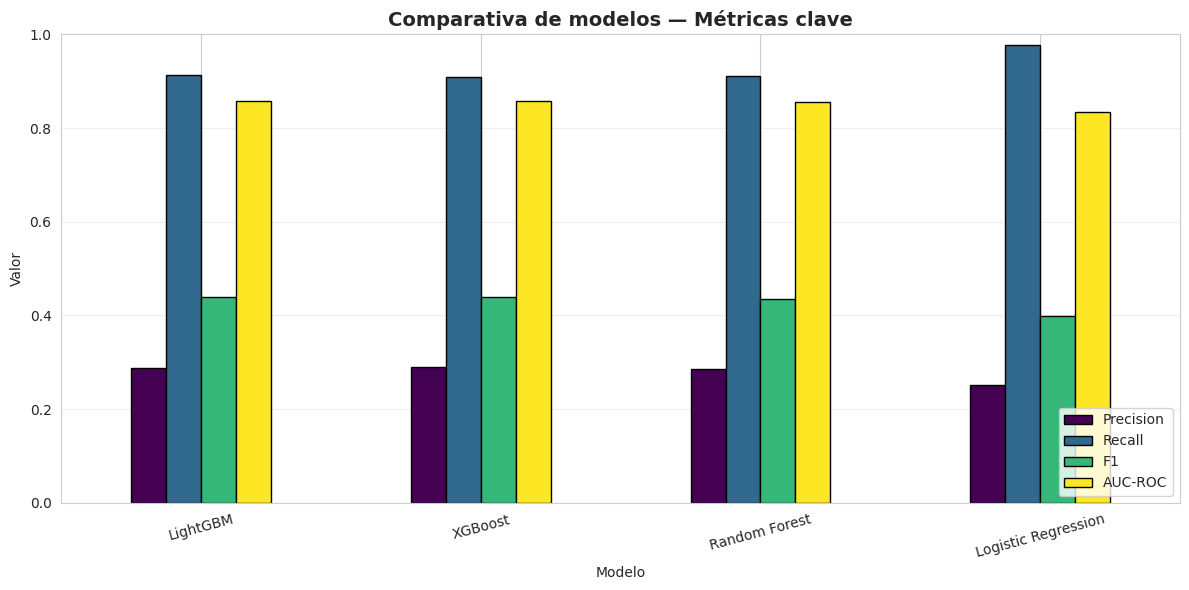

In [11]:
# ============================================================
# GRÁFICO COMPARATIVO DE MÉTRICAS
# ============================================================
metricas_plot = ["Precision", "Recall", "F1", "AUC-ROC"]

fig, ax = plt.subplots(figsize=(12, 6))
df_plot = df_resultados.set_index("Modelo")[metricas_plot]
df_plot.plot(kind="bar", ax=ax, colormap="viridis", edgecolor="black")

ax.set_title("Comparativa de modelos — Métricas clave", fontsize=14, fontweight="bold")
ax.set_ylabel("Valor")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig("outputs/charts/comparativa_modelos.png", dpi=150, bbox_inches="tight")
plt.show()

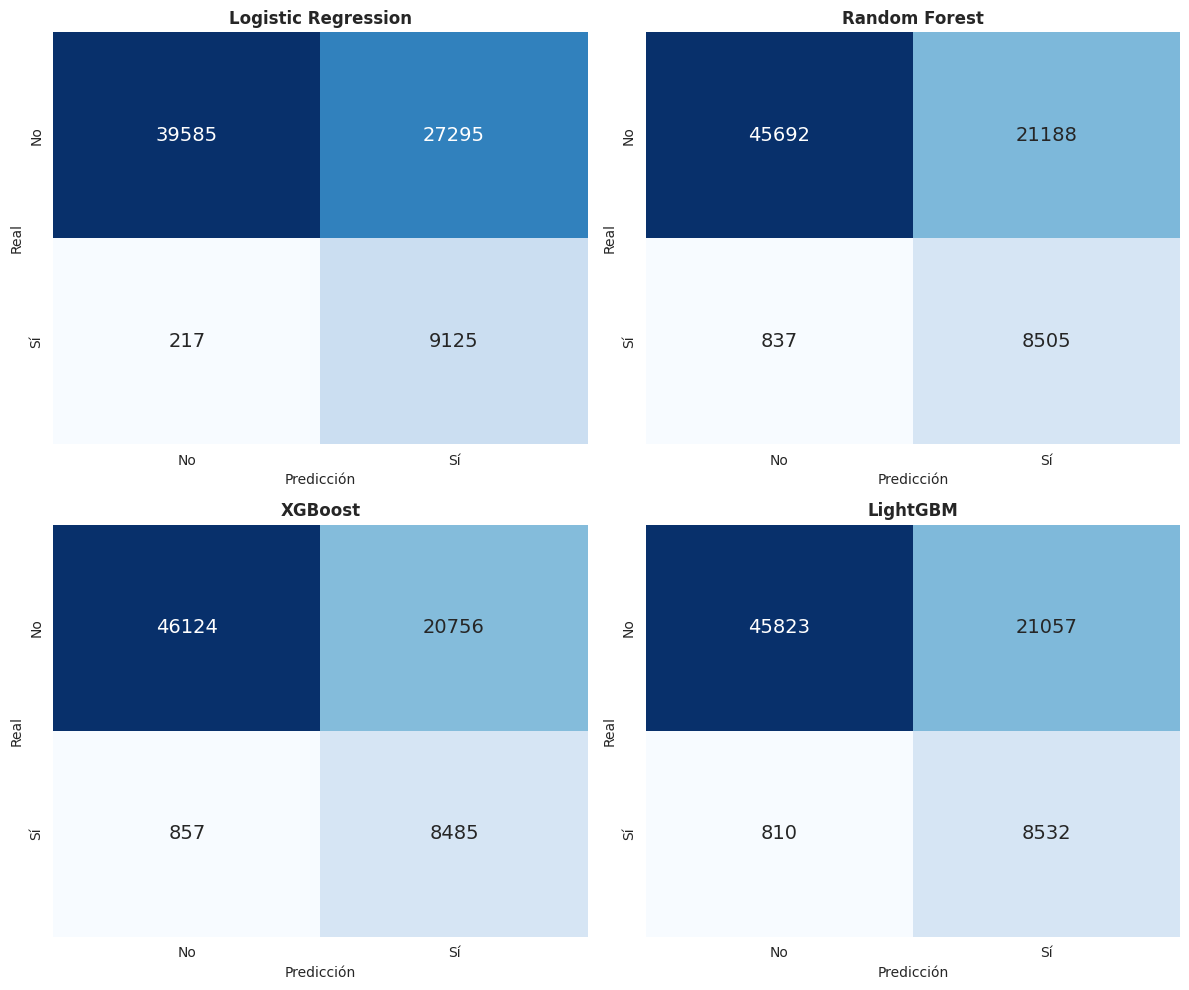

In [12]:
# ============================================================
# MATRICES DE CONFUSIÓN
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (nombre, modelo) in zip(axes, modelos_entrenados.items()):
    y_pred = modelo.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                cbar=False, annot_kws={"size": 14})
    ax.set_title(f"{nombre}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    ax.set_xticklabels(["No", "Sí"])
    ax.set_yticklabels(["No", "Sí"])

plt.tight_layout()
plt.savefig("outputs/charts/matrices_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

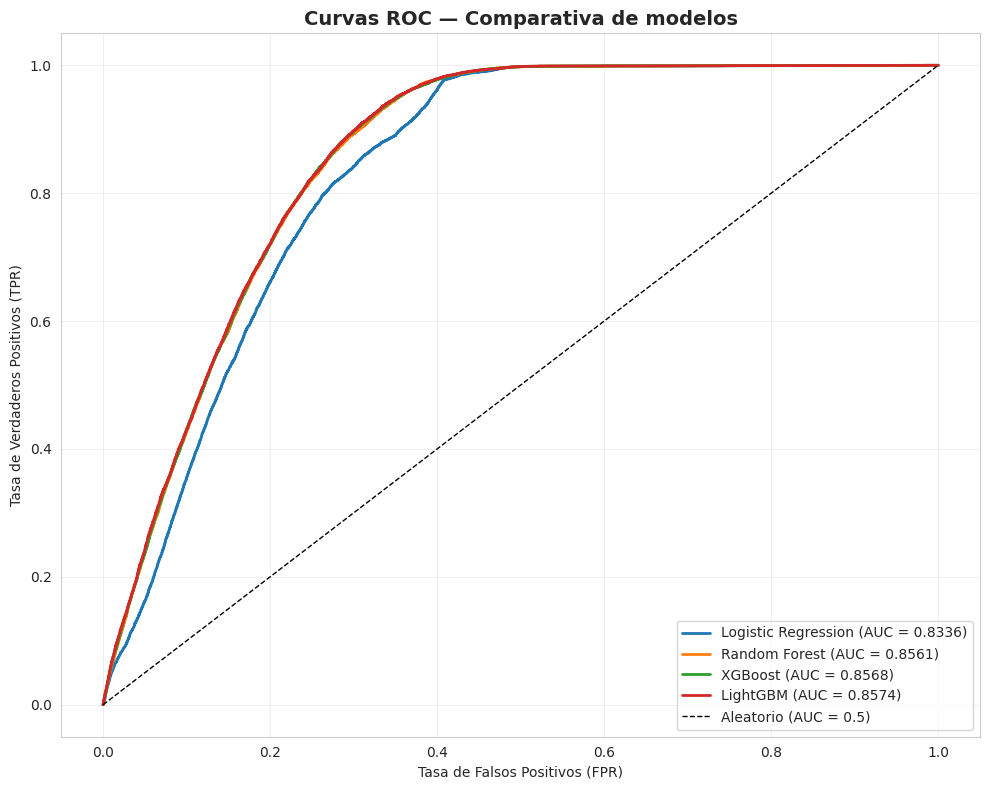

In [13]:
# ============================================================
# CURVAS ROC COMPARADAS
# ============================================================
plt.figure(figsize=(10, 8))

for nombre, modelo in modelos_entrenados.items():
    y_proba = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{nombre} (AUC = {auc:.4f})", linewidth=2)

plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Aleatorio (AUC = 0.5)")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curvas ROC — Comparativa de modelos", fontsize=14, fontweight="bold")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/charts/roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

🏆 Mejor modelo: LightGBM

📊 Importancia de variables:
            Variable  Importancia
             Vintage         1966
                 Age         1768
      Annual_Premium         1764
         Region_Code         1479
Policy_Sales_Channel         1179
         Vehicle_Age          266
              Gender          200
      Vehicle_Damage          199
  Previously_Insured          111
     Driving_License           34


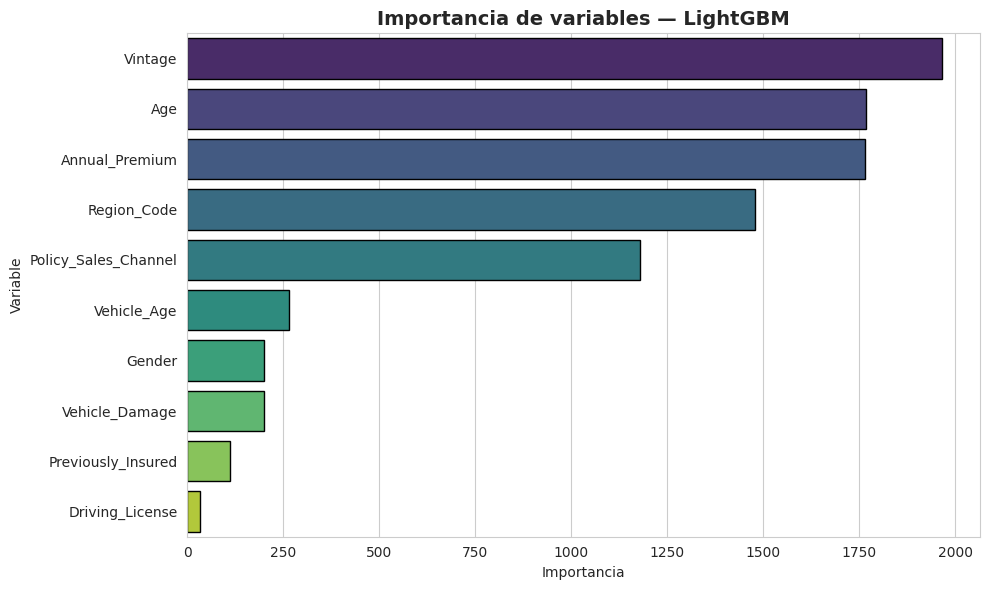

In [14]:
# ============================================================
# IMPORTANCIA DE VARIABLES — Mejor modelo basado en árboles
# ============================================================
# Elegimos el modelo con mejor AUC-ROC que soporte feature_importances_
mejor_nombre = df_resultados.iloc[0]["Modelo"]
mejor_modelo = modelos_entrenados[mejor_nombre]

print(f"🏆 Mejor modelo: {mejor_nombre}")

if hasattr(mejor_modelo, "feature_importances_"):
    importancias = pd.DataFrame({
        "Variable": X_train.columns,
        "Importancia": mejor_modelo.feature_importances_,
    }).sort_values("Importancia", ascending=False)

    print("\n📊 Importancia de variables:")
    print(importancias.to_string(index=False))

    # Guardar
    importancias.to_csv("outputs/metrics/feature_importance.csv", index=False)

    # Gráfico
    plt.figure(figsize=(10, 6))
    sns.barplot(data=importancias, x="Importancia", y="Variable",
                palette="viridis", edgecolor="black")
    plt.title(f"Importancia de variables — {mejor_nombre}",
              fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("outputs/charts/feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Este modelo no soporta feature_importances_")

In [15]:
# ============================================================
# GUARDAR MODELOS ENTRENADOS
# ============================================================
os.makedirs("models/trained", exist_ok=True)

nombres_archivo = {
    "Logistic Regression": "logistic_regression.pkl",
    "Random Forest": "random_forest.pkl",
    "XGBoost": "xgboost.pkl",
    "LightGBM": "lightgbm.pkl",
}

for nombre, modelo in modelos_entrenados.items():
    archivo = f"models/trained/{nombres_archivo[nombre]}"
    joblib.dump(modelo, archivo)
    print(f"✅ Guardado: {archivo}")

✅ Guardado: models/trained/logistic_regression.pkl
✅ Guardado: models/trained/random_forest.pkl
✅ Guardado: models/trained/xgboost.pkl
✅ Guardado: models/trained/lightgbm.pkl


In [16]:
# ============================================================
# DESCARGAR ARTEFACTOS EN ZIP
# ============================================================
import zipfile
from google.colab import files

archivos = [
    "outputs/metrics/metricas_modelos.csv",
    "outputs/metrics/feature_importance.csv",
    "outputs/charts/comparativa_modelos.png",
    "outputs/charts/matrices_confusion.png",
    "outputs/charts/roc_curves.png",
    "outputs/charts/feature_importance.png",
    "models/trained/logistic_regression.pkl",
    "models/trained/random_forest.pkl",
    "models/trained/xgboost.pkl",
    "models/trained/lightgbm.pkl",
]

with zipfile.ZipFile("modelos_ml_artefactos.zip", "w") as zipf:
    for a in archivos:
        if os.path.exists(a):
            zipf.write(a)
            print(f"✅ {a}")
        else:
            print(f"⚠️  NO encontrado: {a}")

files.download("modelos_ml_artefactos.zip")

✅ outputs/metrics/metricas_modelos.csv
✅ outputs/metrics/feature_importance.csv
✅ outputs/charts/comparativa_modelos.png
✅ outputs/charts/matrices_confusion.png
✅ outputs/charts/roc_curves.png
✅ outputs/charts/feature_importance.png
✅ models/trained/logistic_regression.pkl
✅ models/trained/random_forest.pkl
✅ models/trained/xgboost.pkl
✅ models/trained/lightgbm.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 🔍 Conclusiones — Modelos ML clásicos

### Resultados
- Se entrenaron 4 modelos con manejo explícito del desbalanceo de clases.
- **Métricas clave para este problema:** F1-score, Recall y AUC-ROC (no Accuracy).

### Modelos utilizados
| Modelo | Estrategia desbalanceo |
|---|---|
| Logistic Regression | `class_weight="balanced"` |
| Random Forest | `class_weight="balanced"` |
| XGBoost | `scale_pos_weight` |
| LightGBM | `is_unbalance=True` |

### Próximos pasos (notebook 04)
1. Red neuronal profunda (Keras/TensorFlow).
2. Red neuronal + embeddings para variables categóricas.
3. Comparación final con los modelos clásicos.